### Decisio Tree

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Predict class of flower from the perticular class

### Load Dataset

In [23]:
df = pd.read_csv('iris.csv')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


### EDA

In [24]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [25]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [26]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
encoder.fit(df['species'])
df['species']=encoder.transform(df['species'])

In [27]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [28]:
df['species'].value_counts()

species
0    50
1    50
2    50
Name: count, dtype: int64

In [29]:
df.corr()

,sepal_length,sepal_width,petal_length,petal_width,species
sepal_length,1.000000,-0.109369,0.871754,0.817954,0.782561
sepal_width,-0.109369,1.000000,-0.420516,-0.356544,-0.419446
petal_length,0.871754,-0.420516,1.000000,0.962757,0.949043
petal_width,0.817954,-0.356544,0.962757,1.000000,0.956464
species,0.782561,-0.419446,0.949043,0.956464,1.000000


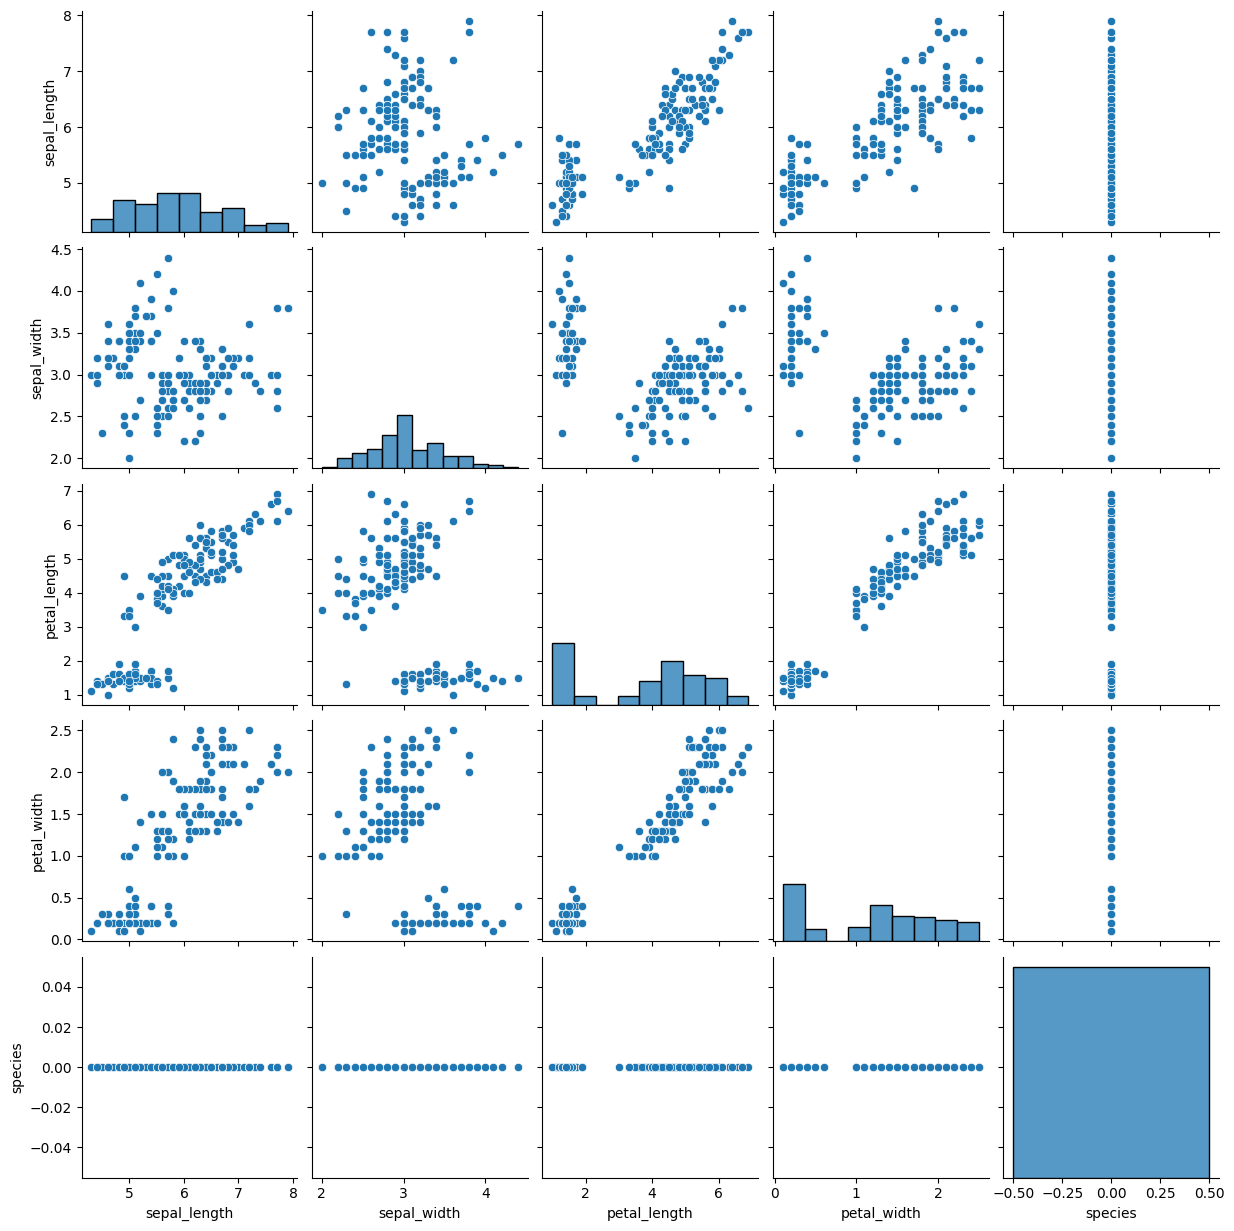

In [17]:
sns.pairplot(df)

In [8]:
df.isna().sum()

age               0
physical_score    0
test_result       0
dtype: int64

In [30]:
# check the Dataset Balance or not 
df['species'].value_counts()

species
0    50
1    50
2    50
Name: count, dtype: int64

### data prepration

In [31]:
x=df.drop('species',axis=1)
y = df['species'] 

In [32]:
from imblearn.over_sampling import SMOTE
smote = SMOTE()
x_new,y_new=smote.fit_resample(x,y)

In [33]:
#Split the train and test 
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x_new,y_new,train_size=0.7,random_state=42)

### Train the Model

In [34]:
from sklearn.tree import DecisionTreeClassifier
def create_dt_model():
    model = DecisionTreeClassifier(max_depth=3)
    model.fit(x_train,y_train)
    return model

In [35]:
from sklearn.svm import SVC
def create_svm_model():
    model = SVC(C=8,kernel='rbf')
    model.fit(x_train,y_train)
    return model

In [36]:
from sklearn.linear_model import LogisticRegressionCV
def creat_Lr_model():
    model = LogisticRegressionCV()
    model.fit(x_train,y_train)
    return model

In [37]:
from sklearn.neighbors import KNeighborsClassifier
def create_knn_model():
    model = KNeighborsClassifier()
    model.fit(x_train,y_train)
    return model

In [38]:
from sklearn.naive_bayes import GaussianNB
def create_naive_model():
    model = GaussianNB()
    model.fit(x_train,y_train)
    return model

### Evaluate The MODEL

### Test Dataset

In [45]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
def evaluate_model(model_name,model,x,y):
    y_pred = model.predict(x)
    accuracy = accuracy_score(y,y_pred)
    precision = precision_score(y,y_pred,average='micro')
    recall = recall_score(y,y_pred,average='micro')
    f1 = f1_score(y,y_pred,average='micro')
    return model_name,accuracy,precision,recall,f1
    

In [46]:
model_dt = create_dt_model()
model_svm = create_svm_model()
model_lr = creat_Lr_model()
model_knn = create_knn_model()
model_naive = create_naive_model()

C:\Users\Hp\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:2092: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
C:\Users\Hp\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:2137: FutureWarning: The default value of the parameter 'scoring' will change from None, i.e. accuracy, to 'neg_log_loss' in version 1.11. To silence this warning, explicitly set the scoring parameter: scoring='neg_log_loss' for the new, scoring='accuracy' or scoring=None for the old default.
  warnings.warn(
C:\Users\Hp\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:2150: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplifie

In [47]:
models = [
    {'model_name':'Descision Tree','model':model_dt},
    {'model_name':'SVM','model':model_svm},
    {'model_name':'Logisttic Regrresion','model':model_lr},
    {'model_name':'KNN','model':model_knn},
    {'model_name':'NNaive','model':model_naive},
]

In [48]:
training_evaluate_metrics=[]
for model_info in models:
    training_evaluate_metrics.append(evaluate_model(model_info['model_name'],model_info['model'],x_train,y_train))
pd.DataFrame(training_evaluate_metrics,columns=['Algo','Accurcy','Presicion','Recall','f1'])

,Algo,Accurcy,Presicion,Recall,f1
0,Descision Tree,0.952381,0.952381,0.952381,0.952381
1,SVM,0.971429,0.971429,0.971429,0.971429
2,Logisttic Regrresion,0.980952,0.980952,0.980952,0.980952
3,KNN,0.952381,0.952381,0.952381,0.952381
4,NNaive,0.942857,0.942857,0.942857,0.942857


### Train dataset

In [49]:
testing_evaluate_metrics=[]
for model_info in models:
    testing_evaluate_metrics.append(evaluate_model(model_info['model_name'],model_info['model'],x_test,y_test))
print("Test Metrics")
pd.DataFrame(testing_evaluate_metrics,columns=['Algo','Accurcy','Presicion','Recall','f1'])

Test Metrics


,Algo,Accurcy,Presicion,Recall,f1
0,Descision Tree,1.000000,1.000000,1.000000,1.000000
1,SVM,1.000000,1.000000,1.000000,1.000000
2,Logisttic Regrresion,1.000000,1.000000,1.000000,1.000000
3,KNN,1.000000,1.000000,1.000000,1.000000
4,NNaive,0.977778,0.977778,0.977778,0.977778


### Find Optimal Values of Hyper Parameters

In [68]:
from sklearn.model_selection import GridSearchCV
parameters={
    'kernel':['linear','polynomial','Sigmoid'],
    'C':[10,8]
}
grideSearch = GridSearchCV(model_svm , param_grid=parameters)
#find optimal Values for hyperparameters
result=grideSearch.fit(x_train,y_train)

C:\Users\Hp\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\model_selection\_validation.py:489: FitFailedWarning: 
20 fits failed out of a total of 30.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\Hp\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\model_selection\_validation.py", line 851, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Hp\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\base.py", line 1393, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "C:\Users\Hp\Ap

In [69]:
result.best_params_

{'C': 10, 'kernel': 'linear'}

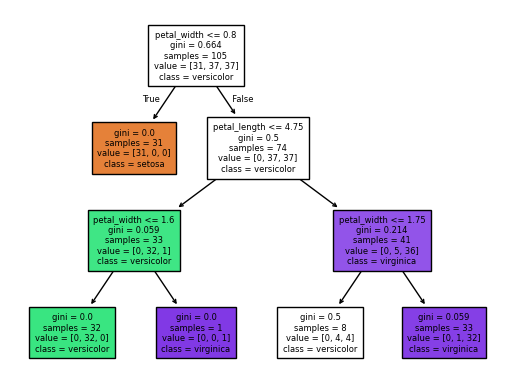

In [52]:
## Visualize the tree
from sklearn.tree import plot_tree

# Change model_svm to model_dt
_ = plot_tree(model_dt, 
              feature_names=['sepal_length', 'sepal_width', 'petal_length', 'petal_width'], 
              class_names=['setosa', 'versicolor', 'virginica'], 
              fontsize=6, 
              filled=True)